### LangGraph Tool calling
#### without using the prebuilt ToolNode

In [1]:
#!pip install ddgs

In [7]:
from langchain_aws import ChatBedrockConverse 
from langchain_experimental.tools import PythonREPLTool 
from typing import TypedDict, Annotated, List 
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool 
from langgraph.graph import START, END, StateGraph 
import operator

In [8]:
#Tool 1
python_tool = PythonREPLTool() 

In [9]:
#Tool 2 
search_engine = DuckDuckGoSearchRun()

In [10]:
#!pip install ddgs

In [11]:
#Tool 3 
@tool
def math_tool(operator: str, a: float, b:float) -> float: 
    """This tool perform the arithmetic calculation when the tools is called"""
    if operator == 'add':
        return a + b 
    elif operator == 'subtraction': 
        return a-b 
    elif operator == 'multiplication':
        return a * b
    else: 
        return a/b if b!=0 else "Error: Division by 0"      

In [12]:
#llm 
llm = ChatBedrockConverse(model_id='cohere.command-r-plus-v1:0', temperature = 0.5, region_name = 'us-east-1', max_tokens = 250)
llm.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': 'effa769a-092d-498a-adfe-fcf74a12f652', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 06 May 2026 04:04:05 GMT', 'content-type': 'application/json', 'content-length': '232', 'connection': 'keep-alive', 'x-amzn-requestid': 'effa769a-092d-498a-adfe-fcf74a12f652'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [374]}, 'model_provider': 'bedrock_converse', 'model_name': 'cohere.command-r-plus-v1:0'}, id='lc_run--019dfb75-07d5-75a3-82c2-55cc025a0c41-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

In [13]:
tools = [python_tool, search_engine, math_tool] 
model_with_tools = llm.bind_tools(tools)

In [14]:
tool_names = {tool.name:tool for tool in tools} 
tool_names

{'Python_REPL': PythonREPLTool(python_repl=PythonREPL(globals={'__name__': 'langchain_experimental.tools.python.tool', '__doc__': 'A tool for running python code in a REPL.', '__package__': 'langchain_experimental.tools.python', '__loader__': <_frozen_importlib_external.SourceFileLoader object at 0x72d23a493970>, '__spec__': ModuleSpec(name='langchain_experimental.tools.python.tool', loader=<_frozen_importlib_external.SourceFileLoader object at 0x72d23a493970>, origin='/home/labuser/.local/lib/python3.10/site-packages/langchain_experimental/tools/python/tool.py'), '__file__': '/home/labuser/.local/lib/python3.10/site-packages/langchain_experimental/tools/python/tool.py', '__cached__': '/home/labuser/.local/lib/python3.10/site-packages/langchain_experimental/tools/python/__pycache__/tool.cpython-310.pyc', '__builtins__': {'__name__': 'builtins', '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.", 

In [15]:
res = model_with_tools.invoke("Multiply 10 and 20")
res.tool_calls

[{'name': 'math_tool',
  'args': {'a': 10, 'b': 20, 'operator': 'multiply'},
  'id': 'tooluse_4nwVcBqNCEkA8YVkzhbQYo',
  'type': 'tool_call'}]

In [16]:
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
class AgentState(TypedDict): 
    messages: Annotated[List[BaseMessage], operator.add]

In [17]:
def llm_node(state:AgentState): 
    """
    Node executes the response either by using the given 
    tools at its disposal or from its pre existing knowledge
    """ 
    response = model_with_tools.invoke(state['messages']) 
    return {'messages': [response]}

In [18]:
def manual_tool_node(state:AgentState): 
    last_message = state['messages'][-1] 
    if not last_message.tool_calls: 
        return {} 
    result = [] 
    for tool_call in last_message.tool_calls: 
        tool_name = tool_call['name']
        tool_args = tool_call['args']
        selected_tool = tool_names.get(tool_name) 
        tool_result = selected_tool.invoke(tool_args)
        result.append(ToolMessage(content = tool_result, tool_call_id = tool_call['id']))
    return {'messages':result}

In [19]:
def should_continue(state:AgentState): 
    last_message = state['messages'][-1] 
    if last_message.tool_calls: 
        return "tool" 
    return END

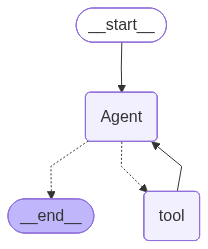

In [20]:
builder = StateGraph(AgentState) 
builder.add_node("Agent", llm_node) 
builder.add_node("tool", manual_tool_node) 
builder.add_conditional_edges("Agent",should_continue, 
                              { 
                                'tool':'tool', 
                                END:END}) 
builder.add_edge(START, "Agent") 
builder.add_edge("Agent", END) 
builder.add_edge("tool","Agent") 
graph = builder.compile()
graph

In [25]:
from rich import print

In [26]:
print(graph.invoke({'messages':['What is the current news in the world of AI ? provide the answer in 1-2 lines.']}))

{
    'messages': [
        'What is the current news in the world of AI ? provide the answer in 1-2 lines.',
        AIMessage(
            content=[
                {'type': 'text', 'text': "I will search for 'AI news' and write a one-line answer."},
                {
                    'type': 'tool_use',
                    'name': 'duckduckgo_search',
                    'input': {'query': 'AI news'},
                    'id': 'tooluse_pXSshZXAbNedB6jgXbxKYN'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': 'a58dfb09-d3ba-43bb-887f-1d45697f8ad8',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:05:35 GMT',
                        'content-type': 'application/json',
                        'content-length': '375',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': 'a58dfb09-d3ba-43bb-887f-1d45697f8ad8'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [1930]},
                'model_provider': 'bedrock_converse',
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='lc_run--019dfb76-6478-7490-9559-216b83749fb6-0',
            tool_calls=[
                {
                    'name': 'duckduckgo_search',
                    'args': {'query': 'AI news'},
                    'id': 'tooluse_pXSshZXAbNedB6jgXbxKYN',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 120,
                'output_tokens': 27,
                'total_tokens': 147,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='AI News is an umbrella term for the continuously updated informational ecosystem reporting on 
artificial intelligence developments, including research results, model releases, product launches, corporate 
strategy, regulation, labor impacts, security… 17 hours ago - AI News delivers the latest updates in artificial 
intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide. 4 hours ago - News 
coverage on artificial intelligence and machine learning tech, the companies building them, and the ethical issues 
AI raises today. 15 hours ago - Newsletters · Watch Live · 8 hrs ago · A tech entrepreneur warns "white-collar 
workers in places like Cardiff" are "in firing line of AI". 8 hrs ago · 8 hrs ago · Candidate lists, constituency 
names and policy details are among the mishaps made by popular chatbots. 4 days ago - Artificial Intelligence: Read
latest updates on AI like Google AI, ChatGPT, Google Lamda, Bard chatbot and more along with latest news as AI 
technology advances and makes new progress. All get detailed articles on AI related queries like what is AI, types 
of artificial intelligence, its applications and future.',
            tool_call_id='tooluse_pXSshZXAbNedB6jgXbxKYN'
        ),
        AIMessage(
            content='AI News covers a range of topics, including research results, model releases, product 
launches, and ethical issues.',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': 'f301cd1f-853a-4d87-ba26-5bba3c307ccb',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:05:42 GMT',
                        'content-type': 'application/json',
                        'content-length': '320',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': 'f301cd1f-853a-4d87-ba26-5bba3c307ccb'


In [28]:
print(graph.invoke({'messages':['Write a python program to generate fibonacci series of 10 numbers']}))

{
    'messages': [
        'Write a python program to generate fibonacci series of 10 numbers',
        AIMessage(
            content=[
                {
                    'type': 'text',
                    'text': 'I will write a Python program to generate the Fibonacci series of 10 numbers.'
                },
                {
                    'type': 'tool_use',
                    'name': 'Python_REPL',
                    'input': {
                        'query': 'def fibonacci(n):\n    fib = [0, 1]\n    while len(fib) < n:\n        
fib.append(fib[-1] + fib[-2])\n    return fib\n\nprint(fibonacci(10))'
                    },
                    'id': 'tooluse_8XV8Xy1z9d7KeisRcRiSs2'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': 'db020f8e-9ce3-4a01-afcf-50bbf99f9e85',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:06:20 GMT',
                        'content-type': 'application/json',
                        'content-length': '522',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': 'db020f8e-9ce3-4a01-afcf-50bbf99f9e85'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [3403]},
                'model_provider': 'bedrock_converse',
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='lc_run--019dfb77-0c82-74b1-96ee-f627e84f8af5-0',
            tool_calls=[
                {
                    'name': 'Python_REPL',
                    'args': {
                        'query': 'def fibonacci(n):\n    fib = [0, 1]\n    while len(fib) < n:\n        
fib.append(fib[-1] + fib[-2])\n    return fib\n\nprint(fibonacci(10))'
                    },
                    'id': 'tooluse_8XV8Xy1z9d7KeisRcRiSs2',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 113,
                'output_tokens': 88,
                'total_tokens': 201,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(content='[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]\n', tool_call_id='tooluse_8XV8Xy1z9d7KeisRcRiSs2'),
        AIMessage(
            content='The Fibonacci series of 10 numbers is:  [0, 1, 1, 2, 3, 5, 8, 13, 21, 34].',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '773fbe88-dfaf-48fd-a2b1-001b6264e5b7',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:06:23 GMT',
                        'content-type': 'application/json',
                        'content-length': '279',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '773fbe88-dfaf-48fd-a2b1-001b6264e5b7'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'end_turn',
                'metrics': {'latencyMs': [3421]},
                'model_provider': 'bedrock_converse',
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='lc_run--019dfb77-1ad9-7973-a1be-8bb607cfdc76-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 174,
                'output_tokens': 44,
                'total_tokens': 218,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        )
    ]
}

## With Tool Node

In [31]:
from langgraph.prebuilt import ToolNode, tools_condition

In [32]:
#!pip install langgraph==0.6.6

In [33]:
tools = [math_tool, search_engine, python_tool] 
model_with_tools = llm.bind_tools(tools) 
tool_node = ToolNode(tools,handle_tool_errors=True)

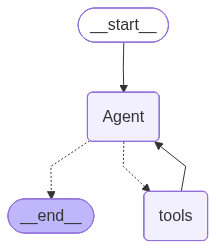

In [34]:
builder1= StateGraph(AgentState) 
builder1.add_node("Agent", llm_node) 
builder1.add_node("tools", tool_node) 
builder1.add_conditional_edges("Agent",tools_condition,) 
builder1.add_edge(START, "Agent") 
builder1.add_edge("tools","Agent") 
builder1.add_edge("Agent", END)
graph1 = builder1.compile()
graph1

In [35]:
res = graph1.invoke({'messages':['When I was 6 years my sister was half my age. Now I am 70 years old, how old is my sister']})
print(res)

{
    'messages': [
        'When I was 6 years my sister was half my age. Now I am 70 years old, how old is my sister',
        AIMessage(
            content=[
                {'type': 'text', 'text': 'I will use the Python REPL to calculate the answer to this question.'},
                {
                    'type': 'tool_use',
                    'name': 'Python_REPL',
                    'input': {
                        'query': '#Calculate the age of the sister\n\n#The sister is half the age of the user when 
the user was 6 years old\nsisters_age = 6/2\n\n#The user is now 70 years old\nusers_age = 70\n\n#Calculate the age 
of the sister now\nsisters_age_now = users_age - sisters_age\n\nprint(f"The sister is now {sisters_age_now} years 
old")'
                    },
                    'id': 'tooluse_hGxJhqG0Tqi6SIeStcrYN9'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': 'f7805ed5-f63e-4d94-8fa9-39d962edc920',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:09:51 GMT',
                        'content-type': 'application/json',
                        'content-length': '692',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': 'f7805ed5-f63e-4d94-8fa9-39d962edc920'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [4603]},
                'model_provider': 'bedrock_converse',
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='lc_run--019dfb7a-43b7-7621-9af6-3b7f50edd780-0',
            tool_calls=[
                {
                    'name': 'Python_REPL',
                    'args': {
                        'query': '#Calculate the age of the sister\n\n#The sister is half the age of the user when 
the user was 6 years old\nsisters_age = 6/2\n\n#The user is now 70 years old\nusers_age = 70\n\n#Calculate the age 
of the sister now\nsisters_age_now = users_age - sisters_age\n\nprint(f"The sister is now {sisters_age_now} years 
old")'
                    },
                    'id': 'tooluse_hGxJhqG0Tqi6SIeStcrYN9',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 126,
                'output_tokens': 133,
                'total_tokens': 259,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='The sister is now 67.0 years old\n',
            name='Python_REPL',
            tool_call_id='tooluse_hGxJhqG0Tqi6SIeStcrYN9'
        ),
        AIMessage(
            content='The sister is now **67 years old**.',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '44c8499e-aa95-4ec1-93a6-45ebab379796',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 06 May 2026 04:09:53 GMT',
                        'content-type': 'application/json',
                        'content-length': '240',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '44c8499e-aa95-4ec1-93a6-45ebab379796'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'end_turn',
                'metrics': {'latencyMs': [1740]},
                'model_provider': 'bedrock_converse',
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='lc_run--019dfb7a-5694-7211-b731-a1fef087bf7a-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
     